# Oscar_FT — Full Training Run with Result Saving

This notebook is identical to V11_oscar.ipynb with one addition:
after the unseen evaluation, all results are saved to `run_results/run_XX.json`
for aggregation by the `aggregate_results.ipynb` script.

**Usage:**
1. Set `RUN_ID` (1–10) at the top of the notebook before running.
2. Run all cells.
3. Results saved to `run_results/run_XX.json`.
4. After 10 runs, open `aggregate_results.ipynb` to generate mean ± std reports.


## 0. Run Configuration — SET THIS BEFORE RUNNING

In [134]:
# ============================================================
# SET RUN_ID TO 1-10 BEFORE EACH RUN
# ============================================================
RUN_ID = 10   # <-- change this for each run (1 through 10)
print(f"Run ID: {RUN_ID}")

Run ID: 10


## 1. Imports and Reproducibility

In [135]:
import os
import json
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# ============================================================
# V11 Oscar — 3 targeted changes from Lima baseline
# ============================================================
#
# 1. TARGET_COUNT raised from 500 to 700
# 2. SpecAugment added on MFCC/Chroma features during training
# 3. Everything else UNCHANGED from Lima
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Paths and Feature Parameters

In [136]:
import numpy as np
import pandas as pd
import librosa as lb

BASE_DIR  = "../dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train-segments")
TEST_DIR  = os.path.join(BASE_DIR, "test-segments")
VAL_DIR   = os.path.join(BASE_DIR, "val-segments")

TRAIN_CSV = os.path.join(BASE_DIR, "train_segments.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test_segments.csv")
VAL_CSV   = os.path.join(BASE_DIR, "val_segments.csv")

SR              = 4000
N_MFCC          = 40
TARGET_MFCC_T   = 679
TARGET_CHROMA_T = 259

## 3. Feature Extraction Helpers

In [137]:
def extract_mfcc_and_chroma(y, sr):
    mfcc   = lb.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    chroma = lb.feature.chroma_stft(y=y, sr=sr)
    return mfcc, chroma


def pad_or_crop(feat, target_T):
    F, T = feat.shape
    if T > target_T:
        return feat[:, :target_T]
    if T < target_T:
        return np.pad(feat, ((0, 0), (0, target_T - T)), mode="constant")
    return feat

## 4. Build Features from CSV

In [138]:
def build_features_from_csv(csv_path, audio_dir):
    df        = pd.read_csv(csv_path)
    mfcc_list = []
    chroma_list = []
    labels    = []

    diseases  = sorted(df["disease"].unique())
    label_map = {d: i for i, d in enumerate(diseases)}

    for _, row in df.iterrows():
        filename  = os.path.basename(row["segment_file"])
        label     = row["disease"]
        file_path = os.path.join(audio_dir, filename)

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing file: {file_path}")

        y, sr        = lb.load(file_path, sr=SR)
        mfcc, chroma = extract_mfcc_and_chroma(y, sr)
        mfcc         = pad_or_crop(mfcc,   TARGET_MFCC_T)
        chroma       = pad_or_crop(chroma, TARGET_CHROMA_T)

        mfcc_list.append(mfcc)
        chroma_list.append(chroma)
        labels.append(label_map[label])

    return np.stack(mfcc_list), np.stack(chroma_list), np.array(labels), label_map

## 5. Load Data

In [139]:
X_mfcc_train, X_chroma_train, y_train, label_map = build_features_from_csv(TRAIN_CSV, TRAIN_DIR)
X_mfcc_test,  X_chroma_test,  y_test,  _         = build_features_from_csv(TEST_CSV,  TEST_DIR)
X_mfcc_val,   X_chroma_val,   y_val,   _         = build_features_from_csv(VAL_CSV,   VAL_DIR)

/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


## 6. Convert to Tensors

In [140]:
X_mfcc_train   = torch.from_numpy(X_mfcc_train).float()
X_chroma_train = torch.from_numpy(X_chroma_train).float()
y_train        = torch.from_numpy(y_train).long()

X_mfcc_test    = torch.from_numpy(X_mfcc_test).float()
X_chroma_test  = torch.from_numpy(X_chroma_test).float()
y_test         = torch.from_numpy(y_test).long()

X_mfcc_unseen   = torch.from_numpy(X_mfcc_val).float()
X_chroma_unseen = torch.from_numpy(X_chroma_val).float()
y_unseen        = torch.from_numpy(y_val).long()

num_classes = len(label_map)
print("Train:",  X_mfcc_train.shape,  X_chroma_train.shape,  y_train.shape)
print("Test: ",  X_mfcc_test.shape,   X_chroma_test.shape,   y_test.shape)
print("Unseen:", X_mfcc_unseen.shape, X_chroma_unseen.shape, y_unseen.shape)
print("Label map:", label_map)

Train: torch.Size([3000, 40, 679]) torch.Size([3000, 12, 259]) torch.Size([3000])
Test:  torch.Size([1027, 40, 679]) torch.Size([1027, 12, 259]) torch.Size([1027])
Unseen: torch.Size([444, 40, 679]) torch.Size([444, 12, 259]) torch.Size([444])
Label map: {'Bronchiectasis': 0, 'Bronchiolitis': 1, 'COPD': 2, 'Healthy': 3, 'Pneumonia': 4, 'URTI': 5}


## 7. Dataset and DataLoader (with SpecAugment)

In [141]:
def spec_augment(feat, freq_mask_width=4, time_mask_width=25, num_masks=2):
    feat = feat.clone()
    F, T = feat.shape

    for _ in range(num_masks):
        f  = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(1, F - f), (1,)).item()
        feat[f0:f0 + f, :] = 0

        t  = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(1, T - t), (1,)).item()
        feat[:, t0:t0 + t] = 0

    return feat


class DualFeatureDataset(Dataset):
    def __init__(self, X_mfcc, X_chroma, y, augment=False):
        assert len(X_mfcc) == len(X_chroma) == len(y)
        self.X_mfcc   = X_mfcc
        self.X_chroma = X_chroma
        self.y        = y
        self.augment  = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        mfcc   = self.X_mfcc[idx]
        chroma = self.X_chroma[idx]

        if self.augment:
            mfcc   = spec_augment(mfcc,   freq_mask_width=4,  time_mask_width=25, num_masks=2)
            chroma = spec_augment(chroma, freq_mask_width=2,  time_mask_width=15, num_masks=2)

        return mfcc, chroma, self.y[idx]


unseen_loader = DataLoader(
    DualFeatureDataset(X_mfcc_unseen, X_chroma_unseen, y_unseen, augment=False),
    batch_size=32, shuffle=False, num_workers=0, pin_memory=True
)

## 8. Model Architecture

In [142]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GatedFusion(nn.Module):
    def __init__(self, dim: int, hidden: int = 128, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
        )

    def forward(self, a: torch.Tensor, b: torch.Tensor):
        w     = torch.clamp(
            torch.sigmoid(self.net(torch.cat([a, b], dim=1))),
            min=0.35, max=0.65
        )
        fused = w * a + (1.0 - w) * b
        return fused, w


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scores  = self.attn(x).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        out     = (weights.unsqueeze(-1) * x).sum(1)
        return out


class DualChannelCNNLSTM_WithAttentionFusion(nn.Module):

    def __init__(self, num_classes: int = 6, dropout_p: float = 0.4, fuse_dim: int = 64):
        super().__init__()
        self.fuse_dim = fuse_dim

        self.mfcc_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(32), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(64), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(128), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
        )
        self.chroma_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(32), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(64), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.BatchNorm2d(128), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
        )
        self.gap2d           = nn.AdaptiveAvgPool2d((1, 1))
        self.mfcc_cnn_proj   = nn.Linear(128, fuse_dim)
        self.chroma_cnn_proj = nn.Linear(128, fuse_dim)

        self.mfcc_lstm1     = nn.LSTM(40,  128, batch_first=True)
        self.mfcc_lstm_drop = nn.Dropout(p=0.3)
        self.mfcc_lstm2     = nn.LSTM(128, fuse_dim, batch_first=True)
        self.mfcc_attn      = TemporalAttention(fuse_dim)
        self.mfcc_lstm_norm = nn.LayerNorm(fuse_dim)

        self.chroma_lstm1     = nn.LSTM(12,  128, batch_first=True)
        self.chroma_lstm_drop = nn.Dropout(p=0.3)
        self.chroma_lstm2     = nn.LSTM(128, fuse_dim, batch_first=True)
        self.chroma_attn      = TemporalAttention(fuse_dim)
        self.chroma_lstm_norm = nn.LayerNorm(fuse_dim)

        self.fuse_cnn_modality  = GatedFusion(fuse_dim, 128, 0.1)
        self.fuse_lstm_modality = GatedFusion(fuse_dim, 128, 0.1)
        self.fuse_extractor     = GatedFusion(fuse_dim, 128, 0.1)

        self.fc1     = nn.Linear(fuse_dim, 128)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_out  = nn.Linear(128, num_classes)

    def forward(self, mfcc: torch.Tensor, chroma: torch.Tensor, return_attn: bool = False):
        mfcc_cnn_vec   = self.gap2d(self.mfcc_cnn(mfcc.unsqueeze(1))).flatten(1)
        mfcc_cnn_vec   = self.mfcc_cnn_proj(mfcc_cnn_vec)

        chroma_cnn_vec = self.gap2d(self.chroma_cnn(chroma.unsqueeze(1))).flatten(1)
        chroma_cnn_vec = self.chroma_cnn_proj(chroma_cnn_vec)

        x, _ = self.mfcc_lstm1(mfcc.transpose(1, 2))
        x     = self.mfcc_lstm_drop(x)
        x, _ = self.mfcc_lstm2(x)
        mfcc_lstm_vec = self.mfcc_lstm_norm(self.mfcc_attn(x))

        y, _ = self.chroma_lstm1(chroma.transpose(1, 2))
        y     = self.chroma_lstm_drop(y)
        y, _ = self.chroma_lstm2(y)
        chroma_lstm_vec = self.chroma_lstm_norm(self.chroma_attn(y))

        cnn_fused,  w_cnn  = self.fuse_cnn_modality(mfcc_cnn_vec,   chroma_cnn_vec)
        lstm_fused, w_lstm = self.fuse_lstm_modality(mfcc_lstm_vec, chroma_lstm_vec)
        final_fused, w_inter = self.fuse_extractor(cnn_fused, lstm_fused)

        z      = F.relu(self.fc1(final_fused))
        z      = self.dropout(z)
        logits = self.fc_out(z)

        if return_attn:
            return logits, {
                "w_cnn_mean":   float(w_cnn.mean().item()),
                "w_lstm_mean":  float(w_lstm.mean().item()),
                "w_inter_mean": float(w_inter.mean().item()),
            }
        return logits

## 9. Early Stopping

In [143]:
@dataclass
class EarlyStopping:
    patience:       int   = 7
    min_delta:      float = 0.0
    best:           float = float("inf")
    num_bad_epochs: int   = 0
    stopped:        bool  = False

    def step(self, current: float) -> bool:
        improved = (self.best - current) > self.min_delta
        if improved:
            self.best           = current
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                self.stopped = True
        return self.stopped


checkpoint_path = f"best_model_run{RUN_ID:02d}.pt"

## 10. Training Loop (run_epoch)

In [144]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, balanced_accuracy_score


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    all_losses, all_preds, all_targets = [], [], []
    attn_w_cnn, attn_w_lstm, attn_w_inter = [], [], []

    for mfcc, chroma, y in loader:
        mfcc   = mfcc.to(device,   non_blocking=True)
        chroma = chroma.to(device, non_blocking=True)
        y      = y.to(device,      non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits, attn = model(mfcc, chroma, return_attn=True)
            loss = criterion(logits, y)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        all_losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())
        attn_w_cnn.append(attn["w_cnn_mean"])
        attn_w_lstm.append(attn["w_lstm_mean"])
        attn_w_inter.append(attn["w_inter_mean"])

    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc     = accuracy_score(all_targets, all_preds)
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )

    return (
        float(np.mean(all_losses)),
        acc, bal_acc, prec, rec, f1,
        float(np.mean(attn_w_cnn)),
        float(np.mean(attn_w_lstm)),
        float(np.mean(attn_w_inter)),
    )

## 11. 10-Fold Cross-Validation


========== Fold 1/10 ==========
  Train: 3308 segs | Val: 103 segs (raw/imbalanced)


/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(


Fold 1 | Epoch 001 | train loss 1.3617 acc 0.1660 f1 0.1460 | val loss 1.1219 acc 0.0194 f1 0.0069 | attn(cnn=0.500, lstm=0.520, inter=0.502) | lr 1.00e-04
Fold 1 | Epoch 002 | train loss 1.3593 acc 0.1778 f1 0.1727 | val loss 1.1047 acc 0.3495 f1 0.0916 | attn(cnn=0.500, lstm=0.525, inter=0.502) | lr 1.00e-04
Fold 1 | Epoch 003 | train loss 1.3466 acc 0.2518 f1 0.2424 | val loss 1.0777 acc 0.3398 f1 0.1039 | attn(cnn=0.502, lstm=0.533, inter=0.501) | lr 1.00e-04
Fold 1 | Epoch 004 | train loss 1.2839 acc 0.3579 f1 0.3445 | val loss 0.8219 acc 0.8252 f1 0.1990 | attn(cnn=0.505, lstm=0.543, inter=0.489) | lr 1.00e-04
Fold 1 | Epoch 005 | train loss 1.1489 acc 0.4531 f1 0.4213 | val loss 0.6276 acc 0.8447 f1 0.1543 | attn(cnn=0.507, lstm=0.551, inter=0.474) | lr 1.00e-04
Fold 1 | Epoch 006 | train loss 1.0380 acc 0.4855 f1 0.4488 | val loss 0.5674 acc 0.8252 f1 0.1825 | attn(cnn=0.508, lstm=0.556, inter=0.457) | lr 1.00e-04
Fold 1 | Epoch 007 | train loss 0.9686 acc 0.5036 f1 0.4771 | va

/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 2 | Epoch 001 | train loss 1.3656 acc 0.1669 f1 0.1364 | val loss 1.1135 acc 0.0485 f1 0.0162 | attn(cnn=0.502, lstm=0.506, inter=0.501) | lr 1.00e-04


...

Fold 7 | Epoch 077 | train loss 0.2029 acc 0.8782 f1 0.8777 | val loss 0.0858 acc 0.9417 f1 0.7120 | attn(cnn=0.495, lstm=0.563, inter=0.448) | lr 1.25e-05


/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 7 | Epoch 078 | train loss 0.2122 acc 0.8691 f1 0.8679 | val loss 0.0815 acc 0.9320 f1 0.7003 | attn(cnn=0.499, lstm=0.563, inter=0.450) | lr 1.25e-05


/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 7 | Epoch 079 | train loss 0.1968 acc 0.8736 f1 0.8724 | val loss 0.0897 acc 0.9126 f1 0.6812 | attn(cnn=0.491, lstm=0.563, inter=0.448) | lr 1.25e-05
Early stopping triggered.

========== Fold 8/10 ==========
  Train: 3308 segs | Val: 102 segs (raw/imbalanced)
Fold 8 | Epoch 001 | train loss 1.3647 acc 0.1717 f1 0.1495 | val loss 1.1264 acc 0.0392 f1 0.0163 | attn(cnn=0.499, lstm=0.501, inter=0.494) | lr 1.00e-04
Fold 8 | Epoch 002 | train loss 1.3562 acc 0.2092 f1 0.2030 | val loss 1.1348 acc 0.1275 f1 0.0911 | attn(cnn=0.500, lstm=0.507, inter=0.495) | lr 1.00e-04
Fold 8 | Epoch 003 | train loss 1.3415 acc 0.2533 f1 0.2477 | val loss 1.1015 acc 0.3627 f1 0.1792 | attn(cnn=0.501, lstm=0.517, inter=0.493) | lr 1.00e-04
Fold 8 | Epoch 004 | train loss 1.2885 acc 0.3374 f1 0.3166 | val loss 0.9666 acc 0.5392 f1 0.2958 | attn(cnn=0.503, lstm=0.530, inter=0.482) | lr 1.00e-04
Fold 8 | Epoch 005 | train loss 1.1856 acc 0.4259 f1 0.3894 | val loss 0.8325 acc 0.6176 f1 0.1768 | attn(cnn

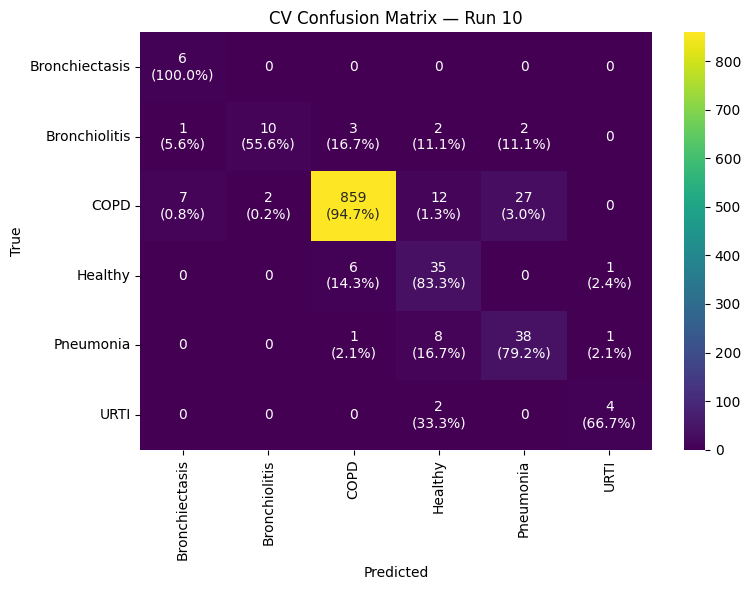

Saved best-fold checkpoint to: best_model_run10.pt


In [145]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns

epochs       = 500
n_splits     = 10
batch_size   = 64
TARGET_COUNT = 700


class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=1.5):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        log_prob      = F.log_softmax(logits, dim=1)
        prob          = torch.exp(log_prob)
        log_prob_true = log_prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        prob_true     = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight  = (1.0 - prob_true) ** self.gamma
        loss          = -focal_weight * log_prob_true
        if self.weight is not None:
            loss = loss * self.weight[targets]
        return loss.mean()


def cap_per_class(mfcc, chroma, y, cap=TARGET_COUNT, seed=SEED):
    rng      = np.random.default_rng(seed)
    keep_idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        if len(cls_idx) > cap:
            cls_idx = rng.choice(cls_idx, cap, replace=False)
        keep_idx.append(cls_idx)
    keep_idx = np.sort(np.concatenate(keep_idx))
    return mfcc[keep_idx], chroma[keep_idx], y[keep_idx]


X_mfcc_train_np   = X_mfcc_train.numpy()   if isinstance(X_mfcc_train,   torch.Tensor) else X_mfcc_train
X_chroma_train_np = X_chroma_train.numpy() if isinstance(X_chroma_train, torch.Tensor) else X_chroma_train
y_train_np        = y_train.numpy()        if isinstance(y_train,        torch.Tensor) else y_train

X_mfcc_test_np    = X_mfcc_test.numpy()    if isinstance(X_mfcc_test,    torch.Tensor) else X_mfcc_test
X_chroma_test_np  = X_chroma_test.numpy()  if isinstance(X_chroma_test,  torch.Tensor) else X_chroma_test
y_test_np         = y_test.numpy()         if isinstance(y_test,         torch.Tensor) else y_test

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

fold_summaries  = []
best_fold_loss  = float("inf")
best_fold_state = None
all_cv_preds    = []
all_cv_targets  = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_test_np)), y_test_np), start=1):
    print(f"\n========== Fold {fold}/{n_splits} ==========")

    fold_val_mfcc   = X_mfcc_test_np[va_idx]
    fold_val_chroma = X_chroma_test_np[va_idx]
    fold_val_y      = y_test_np[va_idx]

    fold_train_mfcc_raw   = np.concatenate([X_mfcc_train_np,   X_mfcc_test_np[tr_idx]],   axis=0)
    fold_train_chroma_raw = np.concatenate([X_chroma_train_np, X_chroma_test_np[tr_idx]], axis=0)
    fold_train_y_raw      = np.concatenate([y_train_np,        y_test_np[tr_idx]],         axis=0)

    fold_train_mfcc, fold_train_chroma, fold_train_y = cap_per_class(
        fold_train_mfcc_raw, fold_train_chroma_raw, fold_train_y_raw, cap=TARGET_COUNT
    )

    print(f"  Train: {len(fold_train_y)} segs | Val: {len(fold_val_y)} segs (raw/imbalanced)")

    fold_train_loader = DataLoader(
        DualFeatureDataset(
            torch.from_numpy(fold_train_mfcc).float(),
            torch.from_numpy(fold_train_chroma).float(),
            torch.from_numpy(fold_train_y).long(),
            augment=True,
        ),
        batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True
    )
    fold_val_loader = DataLoader(
        DualFeatureDataset(
            torch.from_numpy(fold_val_mfcc).float(),
            torch.from_numpy(fold_val_chroma).float(),
            torch.from_numpy(fold_val_y).long(),
            augment=False,
        ),
        batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True
    )

    model = DualChannelCNNLSTM_WithAttentionFusion(
        num_classes=num_classes, dropout_p=0.4, fuse_dim=64,
    ).to(device)

    fold_class_weights = compute_class_weight(
        class_weight="balanced", classes=np.arange(num_classes), y=fold_train_y
    )
    fold_class_weights = torch.tensor(fold_class_weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(weight=fold_class_weights, gamma=1.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6, min_lr=1e-6
    )
    early = EarlyStopping(patience=25, min_delta=1e-4)

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss":   [], "val_acc":   [], "val_f1":   [],
        "lr":         [],
        "train_w_cnn": [], "train_w_lstm": [], "train_w_inter": [],
        "val_w_cnn":   [], "val_w_lstm":   [], "val_w_inter":   [],
    }

    best_this_fold       = float("inf")
    best_state_this_fold = None

    for epoch in range(1, epochs + 1):
        (train_loss, train_acc, train_bal_acc, train_prec, train_rec, train_f1,
         train_w_cnn, train_w_lstm, train_w_inter) = run_epoch(model, fold_train_loader, optimizer=optimizer)

        (val_loss, val_acc, val_bal_acc, val_prec, val_rec, val_f1,
         val_w_cnn, val_w_lstm, val_w_inter) = run_epoch(model, fold_val_loader, optimizer=None)

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]["lr"]

        history["lr"].append(lr)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1);     history["val_f1"].append(val_f1)
        history["train_w_cnn"].append(train_w_cnn);   history["val_w_cnn"].append(val_w_cnn)
        history["train_w_lstm"].append(train_w_lstm);  history["val_w_lstm"].append(val_w_lstm)
        history["train_w_inter"].append(train_w_inter); history["val_w_inter"].append(val_w_inter)

        print(
            f"Fold {fold} | Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"attn(cnn={val_w_cnn:.3f}, lstm={val_w_lstm:.3f}, inter={val_w_inter:.3f}) | "
            f"lr {lr:.2e}"
        )

        if val_loss <= best_this_fold - early.min_delta:
            best_this_fold       = val_loss
            best_state_this_fold = {k: v.detach().cpu().clone()
                                    for k, v in model.state_dict().items()}

        if early.step(val_loss):
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state_this_fold)
    model.eval()

    fold_preds, fold_targets = [], []
    with torch.no_grad():
        for mfcc, chroma, y in fold_val_loader:
            logits = model(mfcc.to(device), chroma.to(device))
            fold_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            fold_targets.append(y.numpy())

    fold_preds   = np.concatenate(fold_preds)
    fold_targets = np.concatenate(fold_targets)
    all_cv_preds.extend(fold_preds)
    all_cv_targets.extend(fold_targets)

    fold_summaries.append({
        "fold":          fold,
        "best_val_loss": best_this_fold,
        "best_val_acc":  max(history["val_acc"]) if history["val_acc"] else float("nan"),
        "best_val_f1":   max(history["val_f1"])  if history["val_f1"]  else float("nan"),
        "history":       history,
    })

    if best_this_fold < best_fold_loss and best_state_this_fold is not None:
        best_fold_loss  = best_this_fold
        best_fold_state = best_state_this_fold


print("\n========== CV Summary ==========")
for s in fold_summaries:
    print(f"Fold {s['fold']}: best val loss={s['best_val_loss']:.4f} | acc={s['best_val_acc']:.4f} | f1={s['best_val_f1']:.4f}")

mean_acc = np.nanmean([s["best_val_acc"] for s in fold_summaries])
mean_f1  = np.nanmean([s["best_val_f1"]  for s in fold_summaries])
print(f"Mean(best val acc): {mean_acc:.4f}")
print(f"Mean(best val f1 ): {mean_f1:.4f}")


all_cv_preds   = np.array(all_cv_preds)
all_cv_targets = np.array(all_cv_targets)

class_names = list(label_map.keys())
cm_cv      = confusion_matrix(all_cv_targets, all_cv_preds)
cm_cv_norm = np.divide(
    cm_cv.astype("float"),
    cm_cv.sum(axis=1, keepdims=True),
    where=cm_cv.sum(axis=1, keepdims=True) != 0,
)
annot_cv = np.empty_like(cm_cv).astype(str)
for i in range(cm_cv.shape[0]):
    for j in range(cm_cv.shape[1]):
        count   = cm_cv[i, j]
        percent = cm_cv_norm[i, j] * 100
        annot_cv[i, j] = "0" if count == 0 else f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=annot_cv, fmt="", cmap="viridis",
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title(f"CV Confusion Matrix — Run {RUN_ID}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


if best_fold_state is not None:
    torch.save(best_fold_state, checkpoint_path)
    print(f"Saved best-fold checkpoint to: {checkpoint_path}")
else:
    print("WARNING: best_fold_state is None — no checkpoint saved.")

## 12. Unseen Test Set Evaluation

Unseen Accuracy : 0.6171
Unseen Macro Precision: 0.3451 | Recall: 0.3723 | F1: 0.3401

Classification report:
                precision    recall  f1-score   support

Bronchiectasis     0.1364    0.2500    0.1765        12
 Bronchiolitis     0.2000    0.3333    0.2500        12
          COPD     0.7767    0.7925    0.7845       294
       Healthy     0.1842    0.3889    0.2500        18
     Pneumonia     0.5122    0.2692    0.3529        78
          URTI     0.2609    0.2000    0.2264        30

      accuracy                         0.6171       444
     macro avg     0.3451    0.3723    0.3401       444
  weighted avg     0.6384    0.6171    0.6184       444



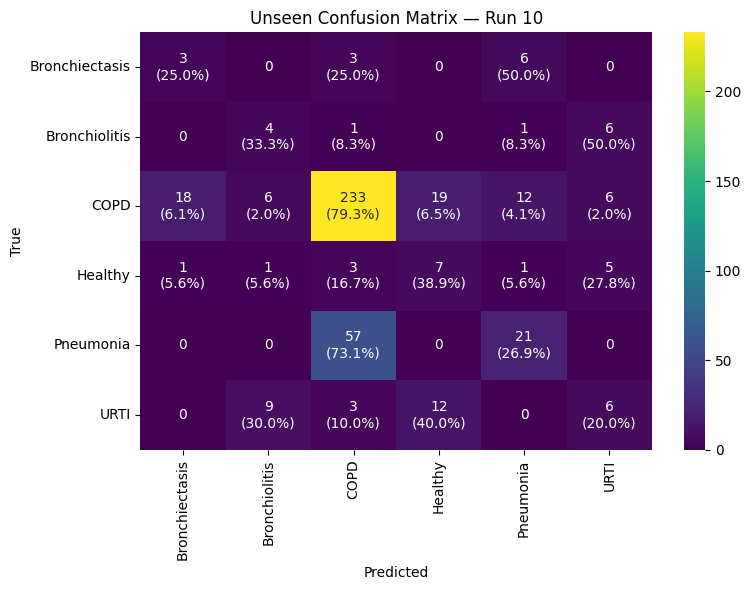

In [146]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for mfcc, chroma, y in unseen_loader:
        logits = model(mfcc.to(device), chroma.to(device))
        all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        all_targets.append(y.numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

acc  = accuracy_score(all_targets, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_targets, all_preds, average="macro", zero_division=0
)
print(f"Unseen Accuracy : {acc:.4f}")
print(f"Unseen Macro Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("\nClassification report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))


cm      = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
annot   = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count   = cm[i, j]
        percent = cm_norm[i, j] * 100
        annot[i, j] = "0" if count == 0 else f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="viridis",
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title(f"Unseen Confusion Matrix — Run {RUN_ID}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

## 13. Save Run Results for Aggregation

In [147]:
# Per-class metrics
per_class_prec, per_class_rec, per_class_f1, _ = precision_recall_fscore_support(
    all_targets, all_preds, average=None, zero_division=0
)

run_results = {
    "run_id":        RUN_ID,
    "unseen_acc":    float(acc),
    "unseen_prec":   float(prec),
    "unseen_rec":    float(rec),
    "unseen_f1":     float(f1),
    "per_class_f1":  {class_names[i]: float(per_class_f1[i])  for i in range(len(class_names))},
    "per_class_prec":{class_names[i]: float(per_class_prec[i]) for i in range(len(class_names))},
    "per_class_rec": {class_names[i]: float(per_class_rec[i])  for i in range(len(class_names))},
    "confusion_matrix": cm.tolist(),
    "label_map":     label_map,
    "fold_summaries": [
        {
            "fold":          s["fold"],
            "best_val_loss": s["best_val_loss"],
            "best_val_acc":  s["best_val_acc"],
            "best_val_f1":   s["best_val_f1"],
            "history":       s["history"],
        }
        for s in fold_summaries
    ],
}

os.makedirs("run_results", exist_ok=True)
save_path = f"run_results/run_{RUN_ID:02d}.json"
with open(save_path, "w") as f:
    json.dump(run_results, f)

print(f"Run {RUN_ID} results saved to: {save_path}")
print(f"  Unseen Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

Run 10 results saved to: run_results/run_10.json
  Unseen Acc=0.6171 | Prec=0.3451 | Rec=0.3723 | F1=0.3401
